# Chapter 4: Anomaly Detection

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Detect credit card fraud **without using labels during training** — use dimensionality reduction (PCA, ICA, Dictionary Learning) and **reconstruction error** as an anomaly score.

---

## What you will learn

1. What **anomaly detection** is and why unsupervised fraud detection adapts to new patterns
2. Prepare the ULB (Université Libre de Bruxelles) credit card dataset structure — synthetic stand-in when CSV is unavailable
3. Stratified train/test split and **StandardScaler** on `V1`–`V28` and `Amount` (Time dropped from modeling features, as in the book workflow)
4. Book helper functions: `anomalyScores`, `plotResults`, `scatterPlot`
5. **PCA (Principal Component Analysis)** anomaly detection — search `n_components` in {10, 20, 27, 29} and pick best by **average precision** on train (29 max when Time is dropped; book uses 30 with Time included)
6. **ICA (Independent Component Analysis / FastICA)** anomaly detection on train
7. **MiniBatchDictionaryLearning** anomaly detection on train
8. Compare PCA, ICA, and Dictionary Learning on the **test set**
9. Understand **anomaly score = normalized reconstruction error** after dimensionality reduction


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | PR (Precision-Recall) and ROC (Receiver Operating Characteristic) curves, scatter plots |
| **scikit-learn (Scientific Kit for Learning)** | PCA, FastICA, MiniBatchDictionaryLearning, scaling, metrics |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import train/test split for stratified fraud detection holdout
from sklearn.model_selection import train_test_split

# Import StandardScaler to put V-features and Amount on comparable scale
from sklearn.preprocessing import StandardScaler

# Import dimensionality reduction algorithms from Chapter 4
from sklearn.decomposition import PCA, FastICA, MiniBatchDictionaryLearning

# Import metrics for imbalanced anomaly ranking evaluation (labels used for assessment only)
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
)

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")


Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Reconstruction error, matrix operations |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Credit card features, anomaly scores, results tables |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and plots | PR/ROC curves, 2D scatter of reduced features |
| **sklearn.model_selection.train_test_split** | Stratified data split | Preserve ~0.5% fraud rate in train and test |
| **sklearn.preprocessing.StandardScaler** | Zero-mean unit-variance scaling | Fair comparison of V1–V28 and Amount |
| **sklearn.decomposition.PCA** | Linear dimensionality reduction | Compress transactions; fraud = high reconstruction error |
| **sklearn.decomposition.FastICA** | Independent Component Analysis | Separate independent sources; anomalies poorly reconstructed |
| **sklearn.decomposition.MiniBatchDictionaryLearning** | Sparse dictionary learning | Represent data with learned basis patterns |
| **sklearn.metrics** | PR curve, ROC curve, average precision | Rank anomalies when labels exist for evaluation |


---

## Algorithms Used in This Notebook

### 1. PCA (Principal Component Analysis) — anomaly detection
- **Type:** Linear dimensionality reduction
- **Idea:** Fit PCA on **normal-looking** training transactions; fraud points lie off the main subspace and reconstruct poorly
- **Anomaly score:** Normalized squared reconstruction error (original − inverse-transformed)
- **Hyperparameter searched:** `n_components` ∈ {10, 20, 27, 29} (29 = feature count without Time)

### 2. FastICA (Independent Component Analysis)
- **Type:** Linear blind source separation
- **Idea:** Find statistically independent components; fraud transactions deviate from typical mixing
- **Anomaly score:** Same reconstruction-error formula after `inverse_transform`

### 3. MiniBatchDictionaryLearning
- **Type:** Sparse coding / dictionary learning
- **Idea:** Learn a dictionary of basis vectors; normal transactions use typical combinations; fraud needs unusual coefficients
- **Anomaly score:** Reconstruction via learned `components_` matrix

### Evaluation note (important for beginners)

These methods are **unsupervised** — they never see `Class` during fitting. We use fraud labels **only** to draw PR/ROC curves and pick hyperparameters, mirroring the book's evaluation workflow. In production you would use expert review or newly confirmed fraud cases.


---

## 1. What Is Anomaly Detection?

**Anomaly detection** flags observations that differ strongly from the bulk of the data.

| | Supervised fraud (Chapter 2) | Unsupervised anomaly detection (Chapter 4) |
|--|------------------------------|---------------------------------------------|
| **Labels in training?** | Yes | No |
| **Strength** | High accuracy when labels are fresh and plentiful | Adapts to **new** fraud patterns without re-labeling |
| **Weakness** | Needs labeled fraud; stale labels miss new attacks | Harder to tune; evaluation needs held-out labels |

**Chapter 4 pipeline:** reduce dimensions → reconstruct → large error ⇒ likely fraud.


---

## 2. Credit Card Fraud Data Preparation

### 2.1 Data Acquisition

The book uses the **ULB (Université Libre de Bruxelles) credit card fraud dataset** from Kaggle / the author's GitHub repository. That CSV (Comma-Separated Values) file is **not available** in this course repo (the original download link returns 404 Not Found).

**Our approach:** We generate a **synthetic dataset** with the same structure as Chapter 2:

| Column | Description |
|--------|-------------|
| `Time` | Seconds elapsed since first transaction (kept in DataFrame; **excluded from modeling**) |
| `V1`–`V28` | PCA (Principal Component Analysis)-like anonymized features |
| `Amount` | Transaction amount |
| `Class` | **0** = normal, **1** = fraud |

- **12,000 rows**
- **~0.5% fraud rate** (severely imbalanced, like real fraud data)

> In production you would load `creditcard.csv` with `pd.read_csv()`. The rest of the workflow is identical.


In [2]:
# Set random seed so the synthetic dataset is reproducible every time you run this cell
RNG = np.random.default_rng(42)

# Define total number of transactions (Chapter 4 teaching subset)
N_SAMPLES = 12000

# Target roughly 0.5% fraud rate (imbalanced classification realistic for fraud)
N_FRAUD = int(N_SAMPLES * 0.005)

# Compute number of normal (legitimate) transactions
N_NORMAL = N_SAMPLES - N_FRAUD

# Build feature matrix for normal transactions: V1-V28 are PCA-like Gaussian features
X_normal = RNG.normal(loc=0.0, scale=1.0, size=(N_NORMAL, 28))

# Build feature matrix for fraud transactions with shifted means on several components
X_fraud = RNG.normal(loc=0.0, scale=1.0, size=(N_FRAUD, 28))

# Shift V1, V5, V14 for fraud to create a learnable signal (mimics real separability)
X_fraud[:, 0] += 2.5

X_fraud[:, 4] -= 1.8

X_fraud[:, 13] += 2.0

# Stack normal and fraud feature rows into one matrix
X_v = np.vstack([X_normal, X_fraud])

# Generate Time column: elapsed seconds (uniform random for synthetic demo)
time_vals = RNG.uniform(0, 172800, size=N_SAMPLES)

# Generate Amount: log-normal distribution (many small amounts, few large ones)
amount_vals = RNG.lognormal(mean=3.0, sigma=1.2, size=N_SAMPLES)

# Fraud transactions tend to be slightly larger on average in our synthetic data
amount_vals[N_NORMAL:] *= 1.4

# Create binary labels: 0 = normal, 1 = fraud (first N_NORMAL rows are normal before shuffle)
y_vals = np.array([0] * N_NORMAL + [1] * N_FRAUD)

# Shuffle all rows together so fraud is not clustered at the end
shuffle_idx = RNG.permutation(N_SAMPLES)

# Apply shuffle index to features, time, amount, and labels together
X_v = X_v[shuffle_idx]

time_vals = time_vals[shuffle_idx]

amount_vals = amount_vals[shuffle_idx]

y_vals = y_vals[shuffle_idx]

# Build column names V1 through V28 matching the real dataset naming
v_cols = [f"V{i}" for i in range(1, 29)]

# Assemble the full DataFrame (two-dimensional labeled data table)
df = pd.DataFrame(X_v, columns=v_cols)

# Add Time column as first column (like the original CSV structure)
df.insert(0, "Time", time_vals)

# Add Amount column before Class label
df["Amount"] = amount_vals

# Add Class label column (used for evaluation only in this chapter)
df["Class"] = y_vals

# Report dataset shape and fraud rate for sanity check
print(f"Synthetic dataset shape: {df.shape}")

print(f"Fraud rate: {df['Class'].mean():.4%} ({df['Class'].sum()} fraud cases)")

# Show first rows so beginners can see the structure
display(df.head())


Synthetic dataset shape: (12000, 31)
Fraud rate: 0.5000% (60 fraud cases)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,113732.780253,-0.703164,0.279344,-0.269390,-0.314917,1.544584,-0.943096,0.433637,-0.479829,0.849555,...,1.102328,0.318653,-0.879434,-2.099098,2.039451,-0.305108,-2.394195,0.288586,10.418019,0
1,77088.183546,-1.259952,-0.830145,0.139384,1.486630,1.622395,-0.091349,-0.642500,1.293675,0.083815,...,0.206738,0.109676,1.607564,0.460043,-0.463303,0.418893,-1.361905,0.191391,52.987494,0
2,57900.383914,-1.751410,-0.201780,-0.312010,1.240411,0.213342,-0.118820,-0.437333,-1.029245,1.204272,...,-0.253281,0.823515,-1.099100,-0.146164,-0.411998,-0.630261,-0.689694,1.468627,50.171578,0
3,24658.019491,0.401232,-0.780910,-0.830289,-0.390313,-0.964583,1.090102,0.314642,0.748978,-0.339731,...,-0.904723,0.085833,1.397502,0.259017,-0.837253,0.752919,1.869451,0.085910,48.834786,0
4,159385.656839,-2.925321,1.525893,-0.649149,-1.647776,1.356614,-0.834498,0.730126,2.340332,0.519543,...,0.287845,-2.325958,0.831192,-0.573601,-0.197009,0.442495,3.072825,-0.009767,36.146055,0


Class distribution:
Class
0    11940
1       60
Name: count, dtype: int64


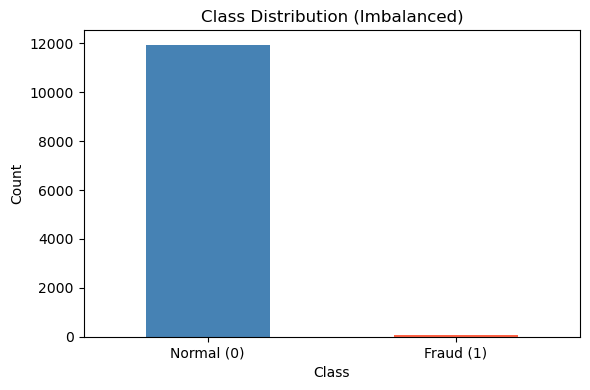

In [3]:
# Check class balance — fraud is rare (typical production scenario)
class_counts = df["Class"].value_counts().sort_index()

print("Class distribution:")

print(class_counts)

# Bar chart of class counts — visual imbalance check
plt.figure(figsize=(6, 4))

class_counts.plot(kind="bar", color=["steelblue", "tomato"])

plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"], rotation=0)

plt.title("Class Distribution (Imbalanced)")

plt.ylabel("Count")

plt.tight_layout()

plt.show()


### 2.2 Train/Test Split and Feature Scaling

Following the book:
- **Stratified** `train_test_split` preserves fraud rate in both sets
- **Features for modeling:** `V1`–`V28` and `Amount` only — **`Time` is dropped** (not scaled or fed to reducers)
- **StandardScaler** fit on train, applied to test (no leakage)


In [4]:
# Random seed used throughout Chapter 4 (matches the book)
RANDOM_STATE = 2018

# Feature columns for anomaly detection — V1-V28 plus Amount; Time excluded
FEATURE_COLS = [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Separate feature matrix X and label vector y (Class)
dataX = df[FEATURE_COLS].copy()

dataY = df["Class"].copy()

# Stratified train/test split — 33% test like the book
X_train, X_test, y_train, y_test = train_test_split(
    dataX,
    dataY,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=dataY,
)

# StandardScaler on training features only, then transform test
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS,
    index=X_train.index,
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS,
    index=X_test.index,
)

# Report split sizes and fraud rates
print(f"Train: {X_train.shape[0]} rows, fraud rate {y_train.mean():.4%}")

print(f"Test:  {X_test.shape[0]} rows, fraud rate {y_test.mean():.4%}")

print(f"Features used: {FEATURE_COLS[:3]} ... {FEATURE_COLS[-1]}  (Time dropped)")


Train: 8040 rows, fraud rate 0.4975%
Test:  3960 rows, fraud rate 0.5051%
Features used: ['V1', 'V2', 'V3'] ... Amount  (Time dropped)


---

## 3. Helper Functions (from the Book)

The author defines three reusable helpers for all dimensionality-reduction anomaly detectors.


In [5]:
# Calculate reconstruction error and normalize to [0, 1] — book's anomalyScores helper
def anomalyScores(originalDF, reducedDF):

    # Squared error per row summed across all features
    loss = np.sum((np.array(originalDF) - np.array(reducedDF)) ** 2, axis=1)

    # Wrap as pandas Series aligned with original index
    loss = pd.Series(data=loss, index=originalDF.index)

    # Min-max normalize so scores are comparable across methods
    loss = (loss - np.min(loss)) / (np.max(loss) - np.min(loss))

    return loss


In [6]:
# Plot Precision-Recall (PR) and ROC (Receiver Operating Characteristic) curves — book's plotResults
def plotResults(trueLabels, anomalyScores, returnPreds=False):

    # Combine true fraud labels with anomaly scores for evaluation
    preds = pd.concat([trueLabels, anomalyScores], axis=1)

    preds.columns = ["trueLabel", "anomalyScore"]

    # Precision-Recall (PR) curve — preferred for imbalanced fraud data
    precision, recall, thresholds = precision_recall_curve(
        preds["trueLabel"], preds["anomalyScore"]
    )

    average_precision = average_precision_score(preds["trueLabel"], preds["anomalyScore"])

    plt.figure(figsize=(6, 5))

    plt.step(recall, precision, color="k", alpha=0.7, where="post")

    plt.fill_between(recall, precision, step="post", alpha=0.3, color="k")

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.ylim([0.0, 1.05])

    plt.xlim([0.0, 1.0])

    plt.title(f"Precision-Recall curve: Average Precision = {average_precision:0.2f}")

    plt.tight_layout()

    plt.show()

    # ROC (Receiver Operating Characteristic) curve
    fpr, tpr, thresholds = roc_curve(preds["trueLabel"], preds["anomalyScore"])

    areaUnderROC = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))

    plt.plot(fpr, tpr, color="r", lw=2, label="ROC curve")

    plt.plot([0, 1], [0, 1], color="k", lw=2, linestyle="--")

    plt.xlim([0.0, 1.0])

    plt.ylim([0.0, 1.05])

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"Receiver operating characteristic: Area under the curve = {areaUnderROC:0.2f}")

    plt.legend(loc="lower right")

    plt.tight_layout()

    plt.show()

    if returnPreds:

        return preds


In [7]:
# Scatter plot of first two reduced dimensions colored by label — book's scatterPlot
def scatterPlot(xDF, yDF, algoName):

    # Take first two components for 2D visualization
    tempDF = pd.DataFrame(data=xDF.iloc[:, 0:2].values, index=xDF.index)

    tempDF = pd.concat((tempDF, yDF), axis=1, join="inner")

    tempDF.columns = ["First Vector", "Second Vector", "Label"]

    # Separate normal vs fraud for matplotlib scatter (no seaborn dependency)
    normal = tempDF[tempDF["Label"] == 0]

    fraud = tempDF[tempDF["Label"] == 1]

    plt.figure(figsize=(7, 5))

    plt.scatter(normal["First Vector"], normal["Second Vector"],
                alpha=0.3, s=12, c="steelblue", label="Normal (0)")

    plt.scatter(fraud["First Vector"], fraud["Second Vector"],
                alpha=0.8, s=40, c="tomato", label="Fraud (1)", marker="x")

    plt.xlabel("First reduced dimension")

    plt.ylabel("Second reduced dimension")

    plt.title(f"Separation of Observations using {algoName}")

    plt.legend()

    plt.tight_layout()

    plt.show()


---

## 4. Anomaly Score = Reconstruction Error

For each transaction **x**:

1. **Encode:** `x_reduced = model.transform(x)` — project into fewer dimensions
2. **Decode:** `x_reconstructed = model.inverse_transform(x_reduced)` (or `components_` dot product for dictionary learning)
3. **Error:** `loss = sum((x - x_reconstructed)²)` across features
4. **Score:** min-max normalize `loss` to **[0, 1]** — **higher score ⇒ more anomalous**

Intuition: the model learns structure from **typical** training transactions. Fraudulent patterns are rare and poorly represented, so they **cannot be reconstructed accurately**.

> Labels are **not** used in steps 1–2. We only use labels afterward to check whether high scores align with fraud.


---

## 5. PCA (Principal Component Analysis) — Search Best `n_components`

The book tries several PCA (Principal Component Analysis) sizes (up to 30 when Time is included). With **Time dropped**, we have 29 modeling features, so we evaluate **average precision** on the **training set** for `n_components` ∈ {10, 20, 27, 29} and keep the winner for test-set evaluation.


In [8]:
# Try multiple PCA (Principal Component Analysis) sizes and record average precision on train
# Max n_components = n_features (29 without Time; book uses 30 with Time included)
pca_candidates = [n for n in [10, 20, 27, 30] if n <= X_train.shape[1]]

pca_search_rows = []

best_ap = -1.0

best_n_components = None

best_pca = None

for n_components in pca_candidates:

    # Fit PCA on scaled training features
    pca = PCA(n_components=n_components, whiten=False, random_state=RANDOM_STATE)

    X_train_PCA = pca.fit_transform(X_train)

    X_train_PCA = pd.DataFrame(data=X_train_PCA, index=X_train.index)

    # Reconstruct back to original feature space
    X_train_PCA_inverse = pca.inverse_transform(X_train_PCA)

    X_train_PCA_inverse = pd.DataFrame(data=X_train_PCA_inverse, index=X_train.index)

    # Anomaly score = normalized reconstruction error
    scores = anomalyScores(X_train, X_train_PCA_inverse)

    ap = average_precision_score(y_train, scores)

    pca_search_rows.append({"n_components": n_components, "average_precision": ap})

    if ap > best_ap:

        best_ap = ap

        best_n_components = n_components

        best_pca = pca

pca_search_df = pd.DataFrame(pca_search_rows)

print(f"Best PCA n_components on train: {best_n_components} (AP = {best_ap:.4f})")

display(pca_search_df)


Best PCA n_components on train: 10 (AP = 0.0078)


,n_components,average_precision
0,10,0.007781
1,20,0.006755
2,27,0.005198


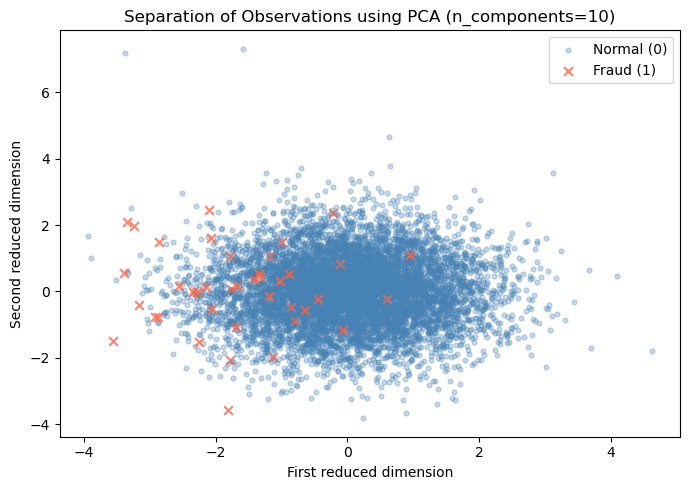

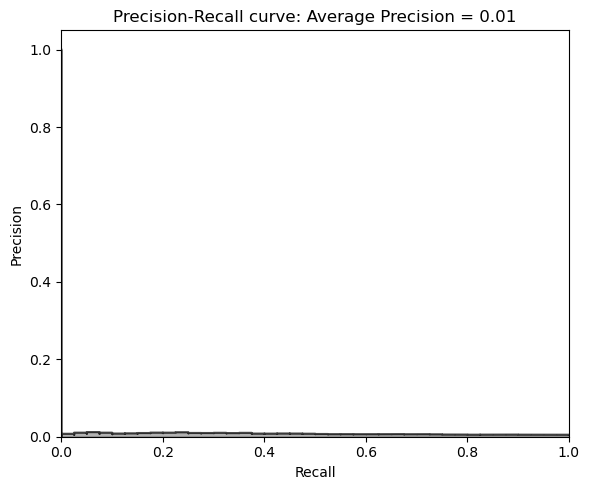

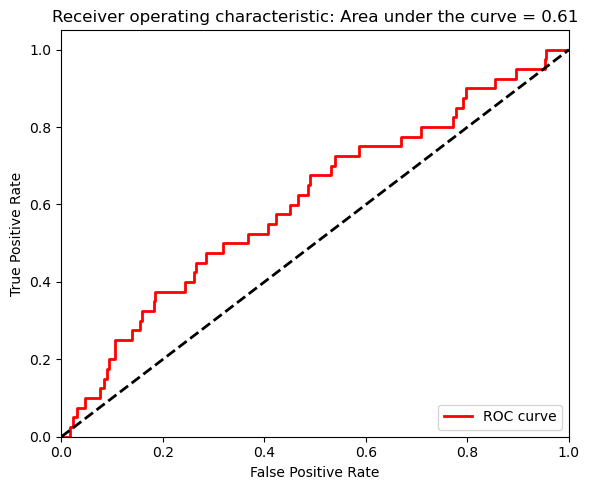

In [9]:
# Refit best PCA (Principal Component Analysis) and visualize train-set separation
pca = best_pca

X_train_PCA = pd.DataFrame(pca.transform(X_train), index=X_train.index)

X_train_PCA_inverse = pd.DataFrame(pca.inverse_transform(X_train_PCA), index=X_train.index)

scatterPlot(X_train_PCA, y_train, f"PCA (n_components={best_n_components})")

anomalyScoresPCA_train = anomalyScores(X_train, X_train_PCA_inverse)

preds_pca_train = plotResults(y_train, anomalyScoresPCA_train, returnPreds=True)


---

## 6. ICA (Independent Component Analysis / FastICA) on Train

FastICA finds statistically **independent components**. We use `n_components=27` (book default) and the same reconstruction-error anomaly score.


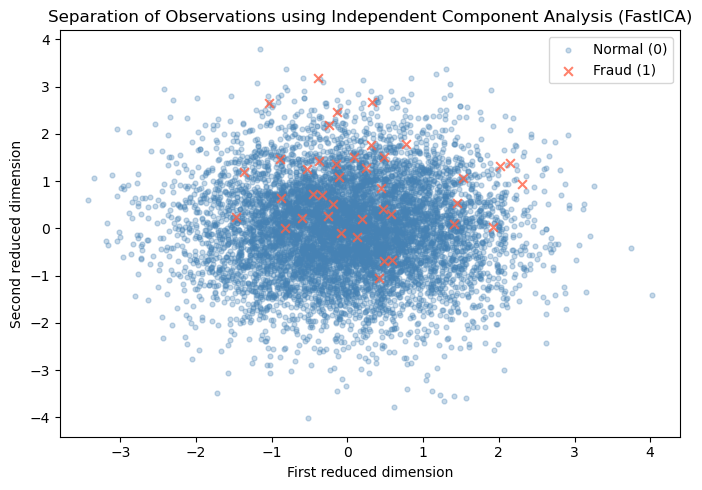

FastICA train average precision: 0.0052


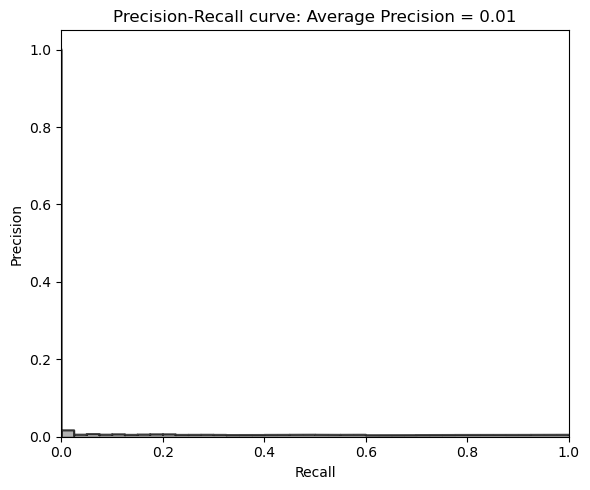

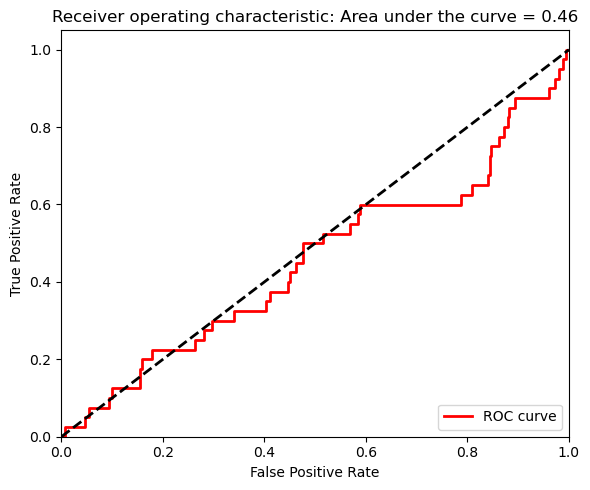

In [10]:
# Fit FastICA (Independent Component Analysis) on training data
n_components_ica = 27

fastICA = FastICA(
    n_components=n_components_ica,
    whiten="unit-variance",
    max_iter=200,
    random_state=RANDOM_STATE,
)

X_train_fastICA = pd.DataFrame(fastICA.fit_transform(X_train), index=X_train.index)

X_train_fastICA_inverse = pd.DataFrame(
    fastICA.inverse_transform(X_train_fastICA), index=X_train.index
)

scatterPlot(X_train_fastICA, y_train, "Independent Component Analysis (FastICA)")

anomalyScoresFastICA_train = anomalyScores(X_train, X_train_fastICA_inverse)

ap_ica_train = average_precision_score(y_train, anomalyScoresFastICA_train)

print(f"FastICA train average precision: {ap_ica_train:.4f}")

plotResults(y_train, anomalyScoresFastICA_train)


---

## 7. MiniBatchDictionaryLearning on Train

**Dictionary learning** represents each transaction as a sparse combination of learned basis vectors. Reconstruction error flags transactions that do not fit typical patterns.


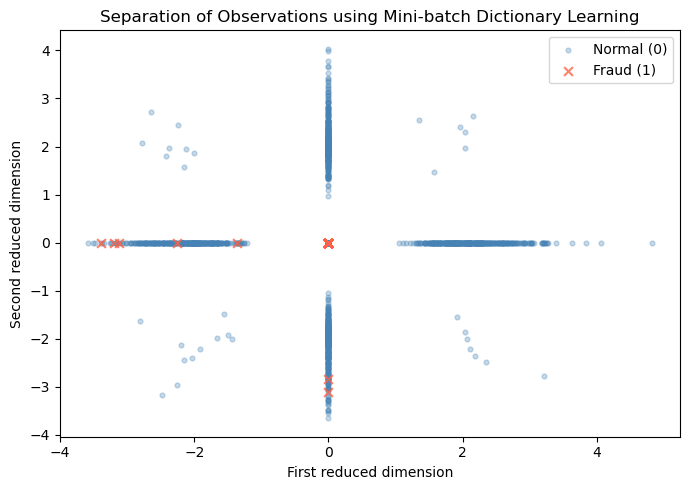

Dictionary Learning train average precision: 0.0453


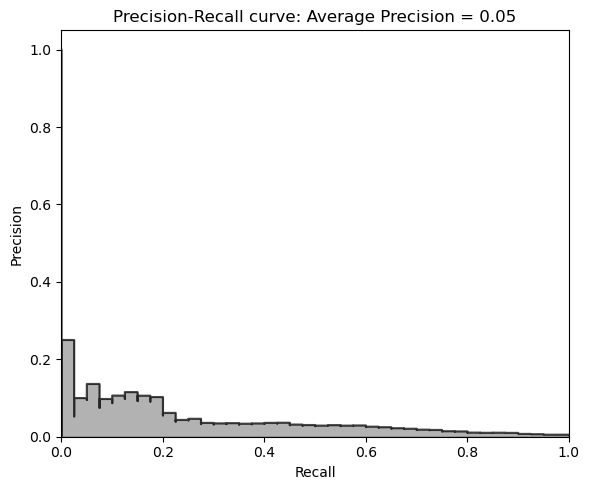

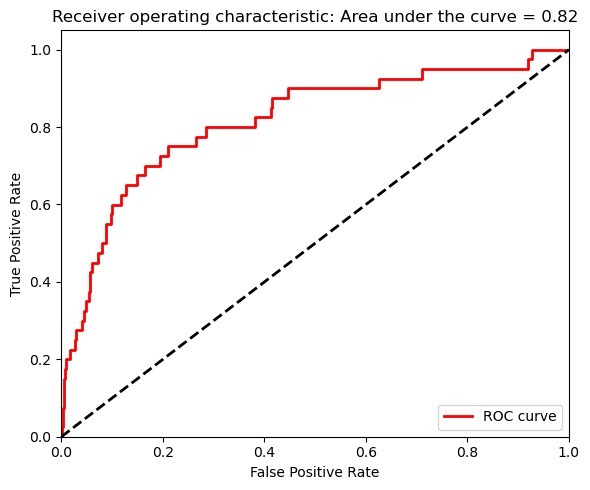

In [11]:
# Fit MiniBatchDictionaryLearning on training data (book hyperparameters)
miniBatchDictLearning = MiniBatchDictionaryLearning(
    n_components=28,
    alpha=1,
    batch_size=200,
    max_iter=10,
    random_state=RANDOM_STATE,
)

miniBatchDictLearning.fit(X_train)

X_train_dict = pd.DataFrame(
    miniBatchDictLearning.transform(X_train), index=X_train.index
)

X_train_dict_inverse = pd.DataFrame(
    np.array(X_train_dict).dot(miniBatchDictLearning.components_),
    index=X_train.index,
)

scatterPlot(X_train_dict, y_train, "Mini-batch Dictionary Learning")

anomalyScoresDict_train = anomalyScores(X_train, X_train_dict_inverse)

ap_dict_train = average_precision_score(y_train, anomalyScoresDict_train)

print(f"Dictionary Learning train average precision: {ap_dict_train:.4f}")

plotResults(y_train, anomalyScoresDict_train)


---

## 8. Test Set Evaluation — Compare PCA, ICA, Dictionary Learning

Models were fit on **train only**. Below we score the **held-out test set** and compare average precision and ROC AUC (Area Under Curve).


In [12]:
# Helper to score test set with a fitted reducer and return metrics
def evaluate_test(originalDF, y_true, reduced_model, method_name, use_dict_inverse=False):

    # Transform test features into reduced space
    X_reduced = pd.DataFrame(reduced_model.transform(originalDF), index=originalDF.index)

    # Reconstruct — dictionary learning uses components_ dot product
    if use_dict_inverse:

        X_inverse = pd.DataFrame(
            np.array(X_reduced).dot(reduced_model.components_), index=originalDF.index
        )

    else:

        X_inverse = pd.DataFrame(
            reduced_model.inverse_transform(X_reduced), index=originalDF.index
        )

    scores = anomalyScores(originalDF, X_inverse)

    ap = average_precision_score(y_true, scores)

    fpr, tpr, _ = roc_curve(y_true, scores)

    roc_auc = auc(fpr, tpr)

    return {"Method": method_name, "Average Precision": ap, "ROC AUC": roc_auc, "scores": scores}

# Evaluate all three methods on test
test_results = []

pca_result = evaluate_test(X_test, y_test, pca, f"PCA (n={best_n_components})")

test_results.append({k: pca_result[k] for k in ["Method", "Average Precision", "ROC AUC"]})

ica_result = evaluate_test(X_test, y_test, fastICA, "FastICA (ICA)")

test_results.append({k: ica_result[k] for k in ["Method", "Average Precision", "ROC AUC"]})

dict_result = evaluate_test(
    X_test, y_test, miniBatchDictLearning, "Dictionary Learning", use_dict_inverse=True
)

test_results.append({k: dict_result[k] for k in ["Method", "Average Precision", "ROC AUC"]})

test_summary_df = pd.DataFrame(test_results)

print("Test-set comparison (labels used for evaluation only):")

display(test_summary_df.assign(
    **{
        "Average Precision": test_summary_df["Average Precision"].map(lambda x: f"{x:.4f}"),
        "ROC AUC": test_summary_df["ROC AUC"].map(lambda x: f"{x:.4f}"),
    }
))


Test-set comparison (labels used for evaluation only):


,Method,Average Precision,ROC AUC
0,PCA (n=10),0.0141,0.6457
1,FastICA (ICA),0.0054,0.4780
2,Dictionary Learning,0.0489,0.8045


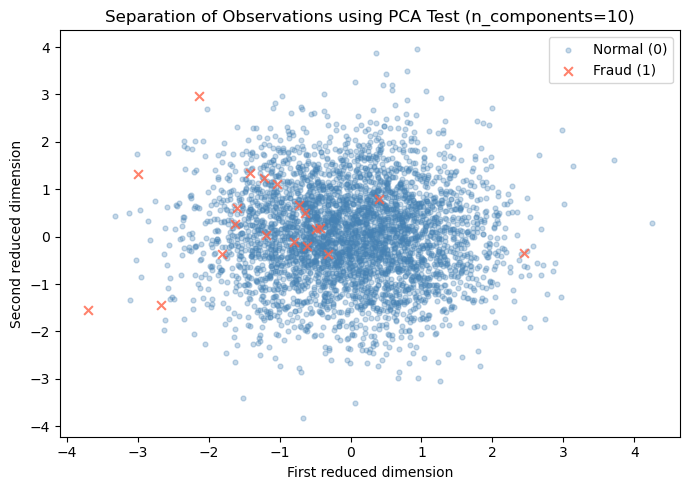

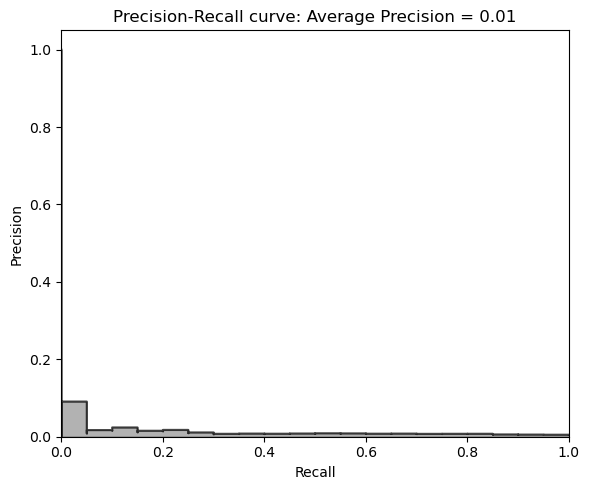

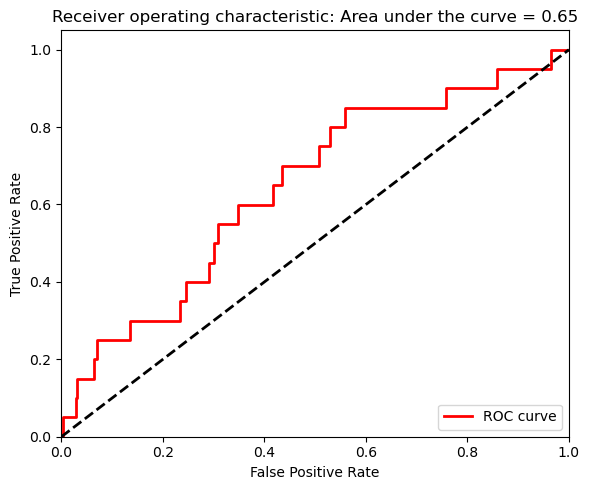

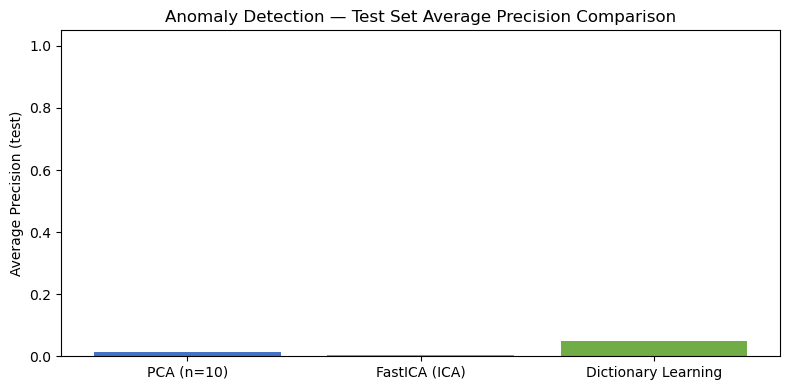

In [13]:
# Plot PR/ROC for best test method and show PCA test scatter for visual check
X_test_PCA = pd.DataFrame(pca.transform(X_test), index=X_test.index)

scatterPlot(X_test_PCA, y_test, f"PCA Test (n_components={best_n_components})")

anomalyScoresPCA_test = pca_result["scores"]

plotResults(y_test, anomalyScoresPCA_test)

# Side-by-side bar chart of test average precision
plt.figure(figsize=(8, 4))

methods = [r["Method"] for r in test_results]

aps = [r["Average Precision"] for r in test_results]

plt.bar(methods, aps, color=["#4472C4", "#ED7D31", "#70AD47"])

plt.ylabel("Average Precision (test)")

plt.title("Anomaly Detection — Test Set Average Precision Comparison")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()


---

## 9. Glossary — All Chapter 4 Terms

| Term | One-line definition |
|------|---------------------|
| **Anomaly detection** | Flag unusual observations that deviate from typical patterns |
| **Reconstruction error** | Squared difference between original and reconstructed feature vector |
| **Anomaly score** | Normalized reconstruction error — higher means more anomalous |
| **PCA (Principal Component Analysis)** | Linear projection onto orthogonal variance-maximizing directions |
| **ICA (Independent Component Analysis)** | Separate mixed signals into statistically independent components |
| **FastICA** | Efficient ICA algorithm in scikit-learn |
| **Dictionary learning** | Represent data as sparse combinations of learned basis vectors |
| **MiniBatchDictionaryLearning** | Scalable online dictionary learning for large datasets |
| **StandardScaler** | Transform features to zero mean and unit variance |
| **Stratified split** | Train/test split preserving class proportions |
| **Average precision** | Summary of Precision-Recall (PR) curve — higher is better for ranking fraud |
| **ROC (Receiver Operating Characteristic)** | True Positive Rate vs False Positive Rate curve |
| **AUC (Area Under Curve)** | Single number summarizing ROC performance |
| **Precision-Recall (PR) curve** | Trade-off between precision and recall at many thresholds |
| **ULB credit card dataset** | Real-world fraud benchmark used in the book |
| **Unsupervised fraud detection** | Detect fraud without training on fraud labels |


---

## 10. Chapter 4 Summary

```
Anomaly Detection (Chapter 4) — Credit card fraud
├── Synthetic ULB-style data (Time, V1-V28, Amount, Class)
├── Prepare: drop Time → scale V1-V28 + Amount → stratified split
├── anomalyScores = normalized reconstruction error
├── PCA — search n_components {10,20,27,29} by train AP (29 max without Time)
├── FastICA (ICA) — independent components + reconstruction error
├── MiniBatchDictionaryLearning — sparse coding + reconstruction error
└── Test-set comparison: PCA vs ICA vs Dictionary Learning

Higher reconstruction error ⇒ higher anomaly score ⇒ likely fraud
```

### What's next?

**Chapter 5** applies **clustering** to MNIST (Modified National Institute of Standards and Technology) digits — k-Means, hierarchical clustering, and DBSCAN (Density-Based Spatial Clustering of Applications with Noise).

---

### Practice questions

1. Why is reconstruction error a reasonable unsupervised fraud score?
2. Why do we drop `Time` from the scaled feature matrix in this workflow?
3. Why is **average precision** often preferred over accuracy for fraud data?
4. What happens if `n_components` for PCA is too small? Too large?
5. How does dictionary learning reconstruction differ from PCA `inverse_transform`?
6. Why might unsupervised fraud detection outperform a stale supervised model in production?
